Training samples: 4800  Testing samples: 1200
Epoch 0  Cost = 0.693147
Epoch 200  Cost = 0.613711
Epoch 400  Cost = 0.608041
Epoch 600  Cost = 0.60569
Epoch 800  Cost = 0.60449
Epoch 1000  Cost = 0.603789
Epoch 1200  Cost = 0.603339
Epoch 1400  Cost = 0.603032
Epoch 1600  Cost = 0.602814
Epoch 1800  Cost = 0.602657
Learning Rate: 0.1  Epochs: 2000
Initial Cost: 0.693147
Final Cost: 0.602543
Bias: 0.0953
Final Weights:
Intensity = -0.1345
Gradient = 0.1322
LocalMean = -0.1282
LocalStd = 1.5885
Laplacian = -0.132
Range = -0.6819
TP = 347  FP = 134  FN = 225  TN = 494
Test Accuracy: 0.7008
Precision: 0.7214
Recall: 0.6066
F1 Score: 0.6591


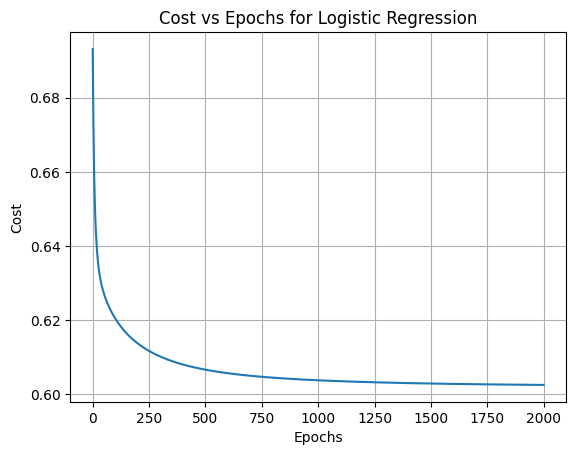

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(30, 100)
X = (X - X.mean(axis=0)) / X.std(axis=0)

p = np.random.permutation(len(X))
X = X[p]
y = y[p]
s = int(0.8 * len(X))
Xtr, Xte = X[:s], X[s:]
ytr, yte = y[:s], y[s:]

print("Training samples:", len(Xtr), " Testing samples:", len(Xte))


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train(X, y, lr, epochs):
    w = np.zeros(X.shape[1])
    b = 0.0
    n = len(X)
    cost_list = []
    for i in range(epochs):
        z = np.dot(X, w) + b
        h = sigmoid(z)
        cost = -np.mean(y * np.log(h + 1e-9) + (1 - y) * np.log(1 - h + 1e-9))
        dw = np.dot(X.T, (h - y)) / n
        db = np.sum(h - y) / n
        w = w - lr * dw
        b = b - lr * db
        cost_list.append(cost)
        if i % 200 == 0:
            print("Epoch", i, " Cost =", round(cost, 6))
    return w, b, cost_list


lr = 0.1
epochs = 2000
w, b, cost_list = train(Xtr, ytr, lr, epochs)

print("Learning Rate:", lr, " Epochs:", epochs)
print("Initial Cost:", round(cost_list[0], 6))
print("Final Cost:", round(cost_list[-1], 6))
print("Bias:", round(b, 4))
print("Final Weights:")
for i in range(len(names)):
    print(names[i], "=", round(w[i], 4))

prob = sigmoid(np.dot(Xte, w) + b)
pred = (prob >= 0.5).astype(int)

tp = int(((pred == 1) & (yte == 1)).sum())
tn = int(((pred == 0) & (yte == 0)).sum())
fp = int(((pred == 1) & (yte == 0)).sum())
fn = int(((pred == 0) & (yte == 1)).sum())
prec = tp / (tp + fp)
rec = tp / (tp + fn)

print("TP =", tp, " FP =", fp, " FN =", fn, " TN =", tn)
print("Test Accuracy:", round((tp + tn) / len(yte), 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1 Score:", round(2 * prec * rec / (prec + rec), 4))

plt.plot(cost_list)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Cost vs Epochs for Logistic Regression")
plt.grid(True)
plt.show()
